In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import timm, types, sys
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from peft import LoraConfig
from peft.tuners.lora import LoraModel
import torchvision.transforms as T

sys.path.append(".")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
CFG = dict(
    data_dir   = "/data/BREAKHIS",
    img_size   = 224,
    batch_size = 64,
    num_workers= 8,
    output_dir = Path("checkpoints/uni_finetuned"),
)

eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
val_ds  = HistologicalImageDataset(f"{CFG['data_dir']}/val",  transform=eval_tf)
test_ds = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=eval_tf)
val_loader  = DataLoader(val_ds,  shuffle=False, batch_size=CFG["batch_size"],
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_ds, shuffle=False, batch_size=CFG["batch_size"],
                          num_workers=CFG["num_workers"], pin_memory=True)
CLASS_NAMES = val_ds.class_names
N_CLASSES   = len(CLASS_NAMES)

Loading from /data/BREAKHIS/val...
Loaded 6832 samples, 8 classes
Class distribution:
  adenosis: 541 (7.9%)
  fibroadenoma: 692 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 601 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 601 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 448 (6.6%)
Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)


In [3]:
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True)
        lora_config = LoraConfig(r=8, lora_alpha=32,
            target_modules=["qkv","proj","fc1","fc2"],
            lora_dropout=0.1, bias="none")
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes))
    def forward(self, x):
        return self.head(self.backbone(x))

model = UNILoRAClassifier(N_CLASSES).to(device)
ckpt  = torch.load(CFG["output_dir"] / "best_model.pt", map_location=device)
model.load_state_dict(ckpt, strict=False)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("Modello caricato")

Modello caricato


In [4]:
def forward_with_oracle_pruning(model, imgs, labels, device,
                                 prune_layer, keep_ratio):
    cache = {}
    orig_blocks = {}

    def make_block_hook(idx):
        orig_block_fwd = model.backbone.model.blocks[idx].forward

        def block_fwd(x):
            # Forward normale del blocco
            x = orig_block_fwd(x)

            if idx == prune_layer:
                # Ora x ha dimensioni corrette — pruning dopo il blocco
                B, N, D = x.shape
                k_keep  = max(1, int((N - 1) * keep_ratio))

                # Score oracle: norma dei token patch (proxy senza hook attenzione)
                scores  = x[:, 1:, :].norm(dim=-1)             # [B, N-1]
                topk    = scores.topk(k_keep, dim=-1).indices   # [B, k_keep]

                cls_tok = x[:, :1, :]                           # [B, 1, D]
                kept    = torch.stack([
                    x[b, 1:][topk[b]] for b in range(B)
                ])                                              # [B, k_keep, D]
                x = torch.cat([cls_tok, kept], dim=1)           # [B, 1+k_keep, D]

            return x
        return block_fwd

    # Hook a livello di Block, non di Attention
    for i, block in enumerate(model.backbone.model.blocks):
        orig_blocks[i] = block.forward
        block.forward  = make_block_hook(i)

    with torch.no_grad():
        logits = model(imgs.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.forward = orig_blocks[i]

    return logits

In [5]:
PRUNE_LAYERS = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
KEEP_RATIOS  = [0.2, 0.3, 0.5]   # 0.2 = rimuovi 80%

results = {}  # {(layer, keep_ratio): acc}

for keep_ratio in KEEP_RATIOS:
    for prune_layer in tqdm(PRUNE_LAYERS, desc=f"keep={keep_ratio}"):
        correct, total = 0, 0
        for imgs, labels in val_loader:
            logits = forward_with_oracle_pruning(
                model, imgs, labels, device, prune_layer, keep_ratio)
            correct += (logits.argmax(-1).cpu() == labels).sum().item()
            total   += len(labels)
        results[(prune_layer, keep_ratio)] = correct / total

# Baseline: nessun pruning
correct, total = 0, 0
for imgs, labels in val_loader:
    with torch.no_grad():
        logits = model(imgs.to(device))
    correct += (logits.argmax(-1).cpu() == labels).sum().item()
    total   += len(labels)
baseline_acc = correct / total
print(f"Baseline (no pruning): {baseline_acc:.3f}")

keep=0.2:   0%|          | 0/11 [00:00<?, ?it/s]

keep=0.3:   0%|          | 0/11 [00:00<?, ?it/s]

keep=0.5:   0%|          | 0/11 [00:00<?, ?it/s]

Baseline (no pruning): 0.953


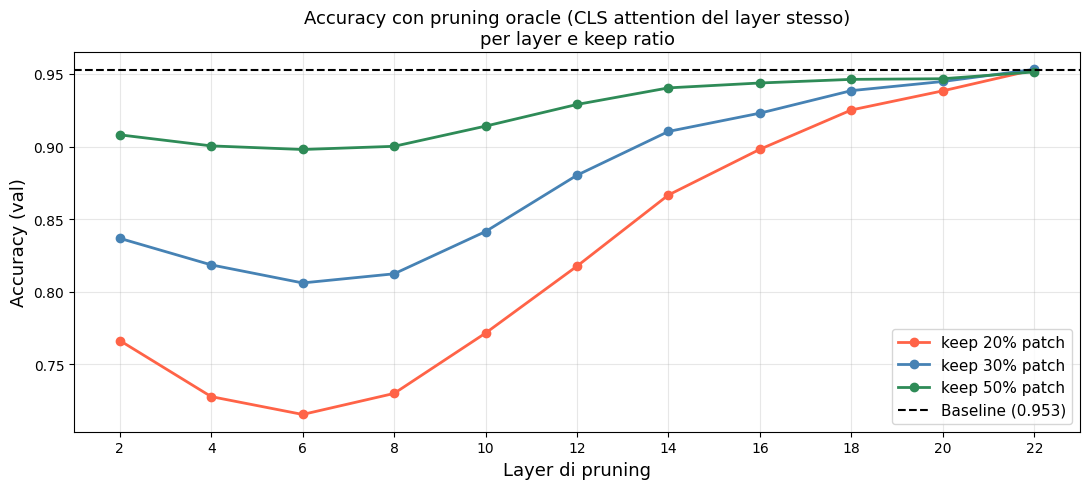


  Layer  keep=20%  keep=30%  keep=50%
──────────────────────────────────────────
      2  0.766(-0.186)  0.837(-0.116)  0.908(-0.044)
      4  0.728(-0.225)  0.819(-0.134)  0.900(-0.052)
      6  0.715(-0.237)  0.806(-0.147)  0.898(-0.055)
      8  0.730(-0.223)  0.812(-0.140)  0.900(-0.052)
     10  0.772(-0.181)  0.841(-0.111)  0.914(-0.038)
     12  0.818(-0.135)  0.880(-0.072)  0.929(-0.024)
     14  0.867(-0.086)  0.910(-0.042)  0.940(-0.012)
     16  0.898(-0.054)  0.923(-0.030)  0.944(-0.009)
     18  0.925(-0.027)  0.939(-0.014)  0.946(-0.006)
     20  0.938(-0.014)  0.945(-0.008)  0.947(-0.006)
     22  0.953(+0.000)  0.953(+0.001)  0.951(-0.001)


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['tomato', 'steelblue', 'seagreen']

for keep_ratio, color in zip(KEEP_RATIOS, colors):
    accs = [results[(l, keep_ratio)] for l in PRUNE_LAYERS]
    ax.plot(PRUNE_LAYERS, accs, marker='o', linewidth=2,
            color=color, label=f"keep {int(keep_ratio*100)}% patch")

ax.axhline(baseline_acc, color='black', linestyle='--',
           linewidth=1.5, label=f"Baseline ({baseline_acc:.3f})")

ax.set_xlabel("Layer di pruning", fontsize=13)
ax.set_ylabel("Accuracy (val)", fontsize=13)
ax.set_title("Accuracy con pruning oracle (CLS attention del layer stesso)\n"
             "per layer e keep ratio", fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(PRUNE_LAYERS)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("oracle_pruning_accuracy.png", dpi=150)
plt.show()

# Tabella
print(f"\n{'Layer':>7}", end="")
for kr in KEEP_RATIOS:
    print(f"  keep={int(kr*100)}%", end="")
print()
print("─" * 42)
for l in PRUNE_LAYERS:
    print(f"{l:>7}", end="")
    for kr in KEEP_RATIOS:
        delta = results[(l, kr)] - baseline_acc
        print(f"  {results[(l,kr)]:.3f}({delta:+.3f})", end="")
    print()

OracleGlobal keep=0.2:   0%|          | 0/11 [00:00<?, ?it/s]

OracleGlobal keep=0.3:   0%|          | 0/11 [00:00<?, ?it/s]

OracleGlobal keep=0.5:   0%|          | 0/11 [00:00<?, ?it/s]

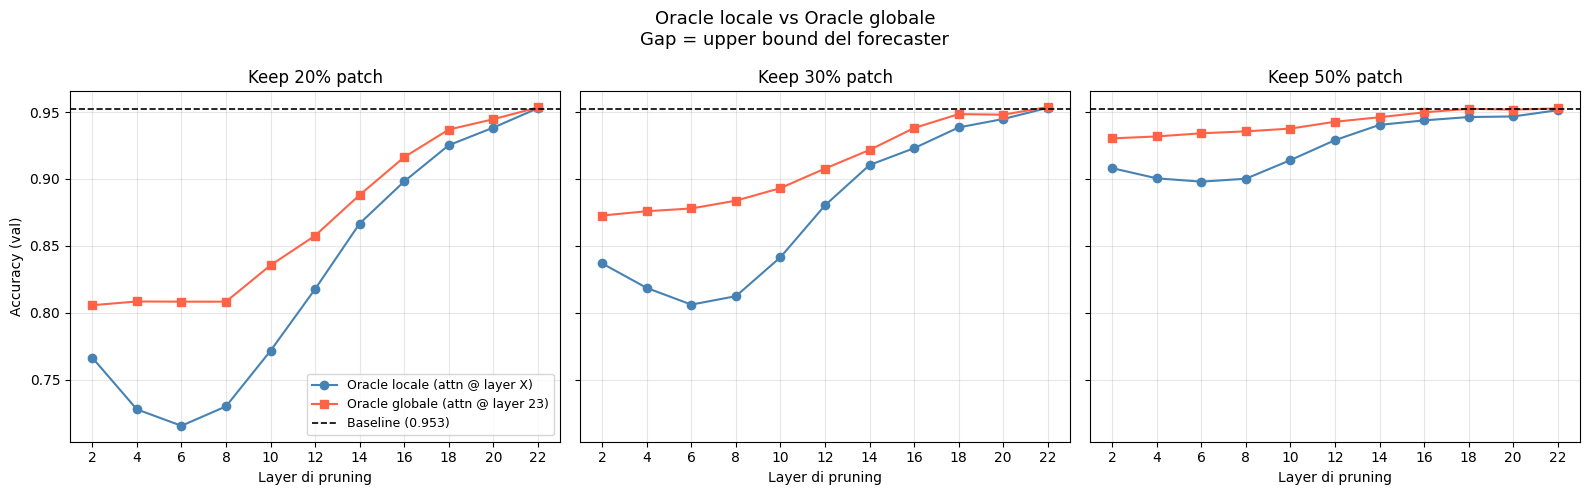


  Layer    keep    Locale    Globale      Gap
─────────────────────────────────────────────
      2     20%     0.766      0.806   +0.039
      4     20%     0.728      0.808   +0.081
      6     20%     0.715      0.808   +0.093
      8     20%     0.730      0.808   +0.078
     10     20%     0.772      0.835   +0.064
     12     20%     0.818      0.858   +0.040
     14     20%     0.867      0.888   +0.021
     16     20%     0.898      0.916   +0.018
     18     20%     0.925      0.937   +0.012
     20     20%     0.938      0.945   +0.006
     22     20%     0.953      0.953   +0.001
      2     30%     0.837      0.873   +0.036
      4     30%     0.819      0.876   +0.057
      6     30%     0.806      0.878   +0.072
      8     30%     0.812      0.884   +0.071
     10     30%     0.841      0.893   +0.052
     12     30%     0.880      0.908   +0.028
     14     30%     0.910      0.922   +0.011
     16     30%     0.923      0.938   +0.015
     18     30%     0.939      0.

In [7]:
# %%
# ─────────────────────────────────────────────────────
# ESPERIMENTO B — Oracle globale (2 forward pass)
# Score = CLS attention @ layer 23 su forward COMPLETO
# poi pruning al layer X con questi score
# ─────────────────────────────────────────────────────
def get_oracle_scores(model, imgs, device, oracle_layer=23):
    """Forward completo — raccoglie CLS attention all'ultimo layer."""
    cache = {}
    orig  = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv = self.qkv(x).reshape(B,N,3,self.num_heads,
                           self.head_dim).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k = self.q_norm(q), self.k_norm(k)
            attn = (q @ k.transpose(-2,-1) * self.scale).softmax(-1)
            if idx == oracle_layer:
                cache["scores"] = attn[:,:,0,1:].mean(1).detach()  # [B, 196]
            x = (self.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
            return self.proj_drop(self.proj(x))
        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    with torch.no_grad():
        model(imgs.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    return cache["scores"]  # [B, 196]


def forward_with_global_oracle(model, imgs, oracle_scores, device,
                                prune_layer, keep_ratio):
    """
    Secondo forward con pruning al prune_layer
    usando oracle_scores precalcolati.
    """
    orig_blocks = {}

    def make_block_hook(idx):
        orig_fwd = model.backbone.model.blocks[idx].forward
        def block_fwd(x):
            x = orig_fwd(x)
            if idx == prune_layer:
                B, N, D = x.shape
                k_keep  = max(1, int((N-1) * keep_ratio))
                scores  = oracle_scores                         # [B, 196]
                topk    = scores.topk(k_keep, dim=-1).indices
                cls_tok = x[:, :1, :]
                kept    = torch.stack([x[b,1:][topk[b]] for b in range(B)])
                x = torch.cat([cls_tok, kept], dim=1)
            return x
        return block_fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig_blocks[i] = block.forward
        block.forward  = make_block_hook(i)

    with torch.no_grad():
        logits = model(imgs.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.forward = orig_blocks[i]

    return logits


# %%
# Loop esperimento B
results_oracle_global = {}

for keep_ratio in KEEP_RATIOS:
    for prune_layer in tqdm(PRUNE_LAYERS, desc=f"OracleGlobal keep={keep_ratio}"):
        correct, total = 0, 0
        for imgs, labels in val_loader:
            # Forward 1: ottieni score globali
            oracle_scores = get_oracle_scores(model, imgs, device, oracle_layer=23)
            # Forward 2: pruning con score globali
            logits = forward_with_global_oracle(
                model, imgs, oracle_scores, device, prune_layer, keep_ratio)
            correct += (logits.argmax(-1).cpu() == labels).sum().item()
            total   += len(labels)
        results_oracle_global[(prune_layer, keep_ratio)] = correct / total


# %%
# Plot comparativo A vs B
fig, axes = plt.subplots(1, len(KEEP_RATIOS), figsize=(16, 5), sharey=True)

for ax, keep_ratio in zip(axes, KEEP_RATIOS):
    acc_local  = [results[(l, keep_ratio)]               for l in PRUNE_LAYERS]
    acc_global = [results_oracle_global[(l, keep_ratio)] for l in PRUNE_LAYERS]

    ax.plot(PRUNE_LAYERS, acc_local,  marker='o', color='steelblue',
            label="Oracle locale (attn @ layer X)")
    ax.plot(PRUNE_LAYERS, acc_global, marker='s', color='tomato',
            label="Oracle globale (attn @ layer 23)")
    ax.axhline(baseline_acc, color='black', linestyle='--',
               linewidth=1.2, label=f"Baseline ({baseline_acc:.3f})")

    ax.set_title(f"Keep {int(keep_ratio*100)}% patch")
    ax.set_xlabel("Layer di pruning")
    ax.set_xticks(PRUNE_LAYERS)
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel("Accuracy (val)")
        ax.legend(fontsize=9)

plt.suptitle("Oracle locale vs Oracle globale\n"
             "Gap = upper bound del forecaster", fontsize=13)
plt.tight_layout()
plt.savefig("oracle_local_vs_global.png", dpi=150)
plt.show()

# Tabella gap
print(f"\n{'Layer':>7}  {'keep':>6}  {'Locale':>8}  {'Globale':>9}  {'Gap':>7}")
print("─" * 45)
for keep_ratio in KEEP_RATIOS:
    for l in PRUNE_LAYERS:
        loc = results[(l, keep_ratio)]
        glo = results_oracle_global[(l, keep_ratio)]
        print(f"{l:>7}  {int(keep_ratio*100):>5}%  {loc:>8.3f}  {glo:>9.3f}  {glo-loc:>+7.3f}")